<div style="
    background: linear-gradient(90deg, #e8f4f3, #dff0ee);
    border: 2px solid #2c7f7b;
    padding: 20px;
    border-radius: 8px;
    font-size: 22px;
    text-align: center;
    margin-top: 30px;
    margin-bottom: 30px;
">
<strong>⚙️ Stage 1 — Setup and Run</strong><br><br>
Configure and launch the Carbonara pipeline.  

Prepare inputs, define the search, start the run, and initialise monitoring of backmapping and FOXS evaluation.
</div>


<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>🧠 Configure search:</strong><br><br>
This cell sets up the main Carbonara search algorithm.  

Provide a project name (<code>run_name</code>), along with the input structure (<code>pdb_name</code>) and SAXS data file (<code>saxs_name</code>).  
Optionally, include a PAE file (<code>pae_name</code>) to guide flexibility.  

The setup will then be initialised. See the README for the full range of configuration options.
</div>

In [1]:
import CarbonaraDataTools as CDT
import numpy as np
import re
import fittingAnalysis as fa
import pickle

# @title Run this to set the carbonara model up with a given run name
run_name = "BSA_MULT_NEW"
pdb_name = "pdbFiles/4F5S_chain1.cif"
saxs_name = "saxsFiles/SASDA32.dat"

# if we have a pae  unhash this and give its location
#pae_name ="<pae_location>"

# choose the number of structures to fit simletaneously
mixture_no = 3

# choose the number of mixture combinations  to try
no_combinations = 40

import sys
!{sys.executable} setup_carbonara_allAtom.py -p $pdb_name -s $saxs_name -n $run_name --rotation --mixture_n $mixture_no --max_mixture_combos $no_combinations 

# for use with pae file (f for flexibility)

#!{sys.executable} setup_carbonara_allAtom.py -p $pdb_name -s $saxs_name -f $pae_name -n $run_name --alphaFoldFlex --rotation --mixture_n mixture_no --max_mixture_combos no_combinations 


import sys
from pathlib import Path

foxs_script = Path("external/pyFoXS/pyFoXS/foxs.py").resolve()
foxs_cmd = f'"{sys.executable}" "{foxs_script}"'

DIR: /extra/tmp/carbonara-refold
/extra/tmp/carbonara-refold
new
Created directory structure in: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT_NEW
The number of chains is  1
100%|██████████████████████████████████████████| 32/32 [00:07<00:00,  4.37it/s]

Setup completed successfully!
Initial files were created in: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT_NEW
Files for Carbonara were copied to: /extra/tmp/carbonara-refold/carbonara_runs/BSA_MULT_NEW
Run script created at: /extra/tmp/carbonara-refold/RunMe_BSA_MULT_NEW.sh
Watcher/backmapping Python: /extra/tmp/carbonara-refold/.venv/bin/python
Run mode: maximal exploration (no individual predictor processes are terminated early)

To run the refinement, execute:
cd /extra/tmp/carbonara-refold && ./RunMe_BSA_MULT_NEW.sh


<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📈 Initial scattering check:</strong><br><br>
This cell runs an initial FoXS check using the starting structure and experimental SAXS data.  
It reports the initial <code>&chi;<sup>2</sup></code> value and shows the corresponding fit and residuals.<br><br>

This gives a quick indication of how well the starting model already agrees with the data.  
In general, a poorer initial fit may mean that Carbonara will need longer to find good-fitting conformations.  
The plot also helps identify where the main discrepancies lie across the scattering curve.<br><br>

You may optionally set a maximum fitting range <code>max_q</code>.  
This can be useful if you want to focus on larger-scale structural features carried by the low-<code>q</code> region.  
For example, the initial fit may improve substantially as the fitted range is restricted, which can indicate that the main mismatch lies at higher <code>q</code>.  
Although Carbonara typically uses <code>q = 0.2</code> as its default upper limit, you may prefer a smaller value such as <code>q = 0.1</code> if your main interest is in low-<code>q</code> behaviour.

['/extra/tmp/carbonara-refold/.venv/bin/python', '/extra/tmp/carbonara-refold/external/pyFoXS/pyFoXS/foxs.py', '/tmp/tmpwwy2k7c2.pdb', '/extra/tmp/carbonara-refold/saxsFiles/SASDA32.dat', '--max_q', '0.2']
Initial FoXS chi^2: 13.7


/extra/tmp/carbonara-refold/CarbonaraDataTools.py:3052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


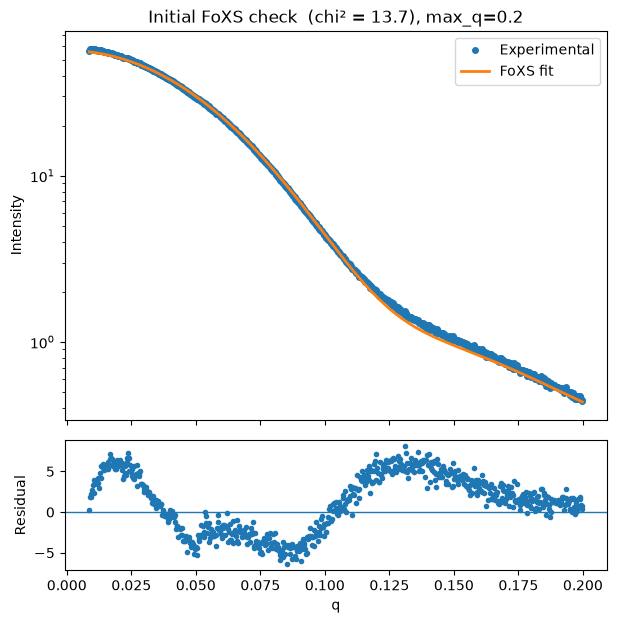

In [2]:
max_q=0.2

foxs_result = CDT.run_initial_foxs_check(
    pdb_name=pdb_name,
    saxs_name=saxs_name,
    foxs_cmd=foxs_cmd,
     max_q =max_q
)

In [ ]:
# if you want to fit on max_q <0.2 (say max_q =0.1) you set it here

CDT.toggle_startk("RunMe_"+run_name+".sh",max_q)

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>🪢 Configure flexibility for the Carbonara search</strong><br><br>
Carbonara can explore anything from subtle local adjustments to large-scale structural rearrangements.  
An initial suggestion of flexible regions is provided (based on AlphaFold PAE or our sheet-preserving approach), but this is only a starting point.<br><br>

You are free to decide exactly how much of the structure is allowed to change.  
In the following steps, you can select which linker sections are flexible, giving you direct control over the scope of the search.
</div>

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 1 — Inspect the available linker sections</strong><br><br>
Run this cell to display the linker regions identified in the structure.  
These are shown both as a highlighted diagram and as a numbered list of residue ranges.
</div>

In [2]:
#grab the list of all linkers and the initally selected ones to assess

selected_secs,fullPossIndicies,fullPoss = CDT.initial_linker_ids(run_name,pdb_name)


In [3]:
# to view the currently selected linkers via the sequence

CDT.view_selected_sections_sequence(run_name)


=== Chain 1 ===
Structure:
-----HHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH----------HHHHHHHHHH----HHHHHHHHHHHHH----HHHHHHH---------------HHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHH--HHHH------HHH--HHHHHHHHHH-------------HHHH-----HHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHH--HHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHH----HHHHHHHHH----HHHHHH--------------HHHH---HHHH---HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHHHHHH-
Sequence:
DTHKSEIAHRFKDLGEEHFKGLVLIAFSQYLQQCPFDEHVKLVNELTEFAKTCVADESHAGCEKSLHTLFGDELCKVASLRETYGDMADCCEKQEPERNECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLYYANKYNGVFQECCQAEDKGACLLPKIETMREKVLTSSARQRLRCASIQKFGERALKAWSVARLSQKFPKAEFVEVTKLVTDLTKVHKECCHGDLLECADDRADLAKYICDNQDTISSKLKECCDKPLLEKSHCIAEVEKDAIPENLPPLTADFAEDKDVCKNYQEAKDAFLGSFLYEYSRRHPEYAVSVLLRLAKEYEATLEECCAKDDPHACYSTVFDKLKH

In [4]:
# to view the currently selected linkers requires Pymol3D installed
fa.visualise_linker_sections(pdb_name,selected_secs)

chain_id_map = None
ignore_chain = False
Applying selection: {'model': 0, 'resi': '1-5'} for Chain 1 ResID: 1-5
Applying selection: {'model': 0, 'resi': '31-35'} for Chain 1 ResID: 31-35
Applying selection: {'model': 0, 'resi': '56-65'} for Chain 1 ResID: 56-65
Applying selection: {'model': 0, 'resi': '76-79'} for Chain 1 ResID: 76-79
Applying selection: {'model': 0, 'resi': '93-96'} for Chain 1 ResID: 93-96
Applying selection: {'model': 0, 'resi': '104-118'} for Chain 1 ResID: 104-118
Applying selection: {'model': 0, 'resi': '145-149'} for Chain 1 ResID: 145-149
Applying selection: {'model': 0, 'resi': '168-172'} for Chain 1 ResID: 168-172
Applying selection: {'model': 0, 'resi': '222-226'} for Chain 1 ResID: 222-226
Applying selection: {'model': 0, 'resi': '271-276'} for Chain 1 ResID: 271-276
Applying selection: {'model': 0, 'resi': '292-304'} for Chain 1 ResID: 292-304
Applying selection: {'model': 0, 'resi': '309-313'} for Chain 1 ResID: 309-313
Applying selection: {'model': 0, 'r

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# to see all the possible fleible sections run this

fa.visualise_linker_sections(pdb_name,fullPoss)

<div style="
    background-color: #f8f9fa;
    border-left: 6px solid #6c757d;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 2 — Choose linker sections</strong><br><br>
Select the linker regions to modify using one of the methods below.  
You can either choose from the numbered list of linker sections, or specify residue ranges directly.
</div>

<div style="
    background-color: #ffffff;
    border-left: 4px solid #0d6efd;
    padding: 10px 14px;
    border-radius: 6px;
    font-size: 14px;
    margin-bottom: 8px;
">
<strong>Option A — Select by linker index (recommended)</strong><br><br>
Choose linker sections using their numbers from the list shown above.<br><br>

Example:<br>
<code>selected_ids = [1, 4, 18, 35]</code><br><br>

This method ensures that only valid linker segments are selected.
</div>

In [ ]:
#check the number of sections to choose from
len(fullPoss)

In [ ]:
# select the linker selections from this range as a list

selected_secs =  [1,6,7,26,33]

# grab the residue id's for these sections

new_selected_secs = CDT.choose_sections_by_number(fullPoss, selected_secs)
new_selected_indicies = CDT.choose_sections_by_number_index(fullPossIndicies, selected_secs)

print("\nNew selection:")
print(new_selected_secs)

<div style="
    background-color: #ffffff;
    border-left: 4px solid #198754;
    padding: 10px 14px;
    border-radius: 6px;
    font-size: 14px;
    margin-bottom: 10px;
">
<strong>Option B — Select by residue ranges</strong><br><br>
Specify regions of interest using residue numbers within each chain.  
Any linker segments overlapping these ranges will be selected automatically.<br><br>

Example:<br>
<code>
user_ranges = {<br>
&nbsp;&nbsp;1: [(5, 12), (234, 287)],<br>
&nbsp;&nbsp;3: [(5, 12)]<br>
}
</code><br><br>

Use this method if you prefer to think in terms of sequence positions rather than linker indices.  
The selected regions can be visualised to confirm the result.
</div>

In [5]:
#Select linker sections by amino acid-chain labelling 

# Make a list, per chain if it is a multimer of chainNo: [(range1),(range2)] of the amino acids to be registered as flexible

#monomer example
user_ranges = {
    1: [(54,63),(292, 313),(349,354)] 
}

#multimer example 
#user_ranges = {
#    1: [(5, 12), (500, 587)]
#    ,
#    3: [(5, 12), (234, 287)]
#}

#get the relevant linker ID's

new_selected_indicies,new_selected_secs = CDT.linker_ids_from_ranges(run_name,pdb_name,user_ranges)

new_selected_secs

['Chain 1 ResID: 56-65', 'Chain 1 ResID: 292-304', 'Chain 1 ResID: 309-313']

<div style="
    background-color: #fff3cd;
    border-left: 6px solid #d39e00;
    padding: 12px 16px;
    border-radius: 6px;
    font-size: 15px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>Step 3 — Preview and apply changes</strong><br><br>
Run this cell to preview the updated selection.  
Only apply the changes permanently once the highlighted regions match the intended linker sections. This is in the final box, do not forget it, or the changed you have made won't be passed to the fitting script.
</div>

In [6]:
# to view the currently selected linkers via the sequence

CDT.view_newly_selected_sections_sequence(run_name,new_selected_indicies)


=== Chain 1 ===
Structure:
-----HHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH----------HHHHHHHHHH----HHHHHHHHHHHHH----HHHHHHH---------------HHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHH--HHHH------HHH--HHHHHHHHHH-------------HHHH-----HHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHH--HHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHH----HHHHHHHHH----HHHHHH--------------HHHH---HHHH---HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHHHHHH-
Sequence:
DTHKSEIAHRFKDLGEEHFKGLVLIAFSQYLQQCPFDEHVKLVNELTEFAKTCVADESHAGCEKSLHTLFGDELCKVASLRETYGDMADCCEKQEPERNECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLYYANKYNGVFQECCQAEDKGACLLPKIETMREKVLTSSARQRLRCASIQKFGERALKAWSVARLSQKFPKAEFVEVTKLVTDLTKVHKECCHGDLLECADDRADLAKYICDNQDTISSKLKECCDKPLLEKSHCIAEVEKDAIPENLPPLTADFAEDKDVCKNYQEAKDAFLGSFLYEYSRRHPEYAVSVLLRLAKEYEATLEECCAKDDPHACYSTVFDKLKH

In [7]:
# see what you have chosen!

fa.visualise_linker_sections(pdb_name,new_selected_secs)

chain_id_map = None
ignore_chain = False
Applying selection: {'model': 0, 'resi': '56-65'} for Chain 1 ResID: 56-65
Applying selection: {'model': 0, 'resi': '292-304'} for Chain 1 ResID: 292-304
Applying selection: {'model': 0, 'resi': '309-313'} for Chain 1 ResID: 309-313
Parsed sections: [(1, 56, 65), (1, 292, 304), (1, 309, 313)]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [15]:
# Set these new linker selections in place  (note for the inital example here we recommend you use the default options!)

CDT.write_varysections_file(new_selected_indicies,"carbonara_runs/"+run_name)

'carbonara_runs/BSA_MULT_NEW/varyingSectionSecondary1.dat'

In [16]:
# double check they are changed (note for the inital example here we recommend you use the default options!)

CDT.view_selected_sections_sequence(run_name)


=== Chain 1 ===
Structure:
-----HHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH----------HHHHHHHHHH----HHHHHHHHHHHHH----HHHHHHH---------------HHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHH--HHHH------HHH--HHHHHHHHHH-------------HHHH-----HHHHHHH-HHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHH--HHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH----HHHHHHHHHHHHHHHHHHHHHHHHH----HHHHHHHHH----HHHHHH--------------HHHH---HHHH---HHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHHHH---HHHHHHHHHHHHHHHHHHHH-
Sequence:
DTHKSEIAHRFKDLGEEHFKGLVLIAFSQYLQQCPFDEHVKLVNELTEFAKTCVADESHAGCEKSLHTLFGDELCKVASLRETYGDMADCCEKQEPERNECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLYYANKYNGVFQECCQAEDKGACLLPKIETMREKVLTSSARQRLRCASIQKFGERALKAWSVARLSQKFPKAEFVEVTKLVTDLTKVHKECCHGDLLECADDRADLAKYICDNQDTISSKLKECCDKPLLEKSHCIAEVEKDAIPENLPPLTADFAEDKDVCKNYQEAKDAFLGSFLYEYSRRHPEYAVSVLLRLAKEYEATLEECCAKDDPHACYSTVFDKLKH

<div style="
    background-color: #eef6f6;
    border-left: 6px solid #2c7f7b;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>⚙️ Initialise run:</strong><br><br>
This cell starts the Carbonara pipeline and initialises the live monitoring system.  
As the search progresses, the monitor performs all-atom backmapping and FoXS evaluation on generated structures.<br><br>

Choose a <code>&chi;<sup>2</sup></code> threshold to define what constitutes a <em>high-quality</em> fit (for example, <code>threshold = 2.5</code> selects structures with <code>&chi;<sup>2</sup> &lt; 2.5</code>).<br><br>

The parameter <code>defer_backmap_seconds</code> controls how long the algorithm waits before beginning all-atom reconstruction.  
If the initial structure is a poor fit, early iterations often produce many intermediate improvements that are not yet high quality.  
Delaying backmapping (e.g. 600 seconds) reduces backlog and focuses computation on more promising structures.<br><br>

The parameter <code>every_s</code> sets how frequently the monitor updates (in seconds), controlling how often new results are checked and processed.
</div>

In [17]:
from pathlib import Path
from run_frontend import CarbonaraRunner

runner = CarbonaraRunner(run_name, foxs_cmd=foxs_cmd)
runner.start()
runner.start_monitor(threshold=2.5, every_s=10, defer_backmap_seconds=600)

✅ Biopython/Bio.PDB check passed
ℹ️ No backmapping method detected in run script; skipping MODELLER preflight check
🚀 Carbonara started (PID=1671445)
🐍 Watcher/backmapping Python: /extra/tmp/carbonara-refold/.venv/bin/python


## 🔬 Carbonara Live Monitor

**Status:** Backmapping window active. New eligible predictions should now be picked up.
**Monitor threshold (χ²):** 2.5
**Mixture components:** 3
**Run mode:** maximal exploration
**Good models:** 81 / 235
**Errors:** 0
**Best χ²:** 1.2814
**Last sweep:** 09:44:05

📊 Monitoring started (mixture_n=3, mode=maximal exploration)


<div style="
    background-color: #fdecea;
    border-left: 6px solid #d9534f;
    padding: 12px;
    border-radius: 6px;
    font-size: 16px;
">
<strong>🛑 Terminate run:</strong><br><br>
Run this cell to stop Carbonara.  

It will be terminated.
</div>

In [18]:
runner.stop()
runner.stop_monitor()

🛑 Stopping Carbonara...
✅ Stopped
📊 Monitoring stopped


<div style="
    background: linear-gradient(90deg, #f4f1fb, #e9e4f7);
    border: 2px solid #7a5cc;
    padding: 20px;
    border-radius: 8px;
    font-size: 22px;
    text-align: center;
    margin-top: 30px;
    margin-bottom: 30px;
">
<strong>📊 STAGE 2 — ANALYSIS</strong><br><br>
Analyse the generated predictions, quantify structural variation, and interpret ensemble behaviour.<br><br>

<div style="
    background-color: #ffffff;
    border-left: 5px solid #7a5cc;
    padding: 10px;
    font-size: 16px;
    border-radius: 5px;
">
<strong>⏱️ You can start this immediately.</strong><br>
There is no need to wait for the Carbonara run to finish — analysis can be performed while the algorithm is still running.
</div>
</div>

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📥 Collect predictions:</strong><br><br>
At this stage you can gather predictions in one of two ways.<br><br>

Use the <em>all predictions</em> option to collect every structure that passes the chosen <code>&chi;<sup>2</sup></code> threshold.  
This is useful for more detailed or advanced analysis, but may include many closely related structures, especially from the same run.<br><br>

Use the <em>best per run</em> option to collect just one representative structure from each run, chosen as the prediction whose <code>&chi;<sup>2</sup></code> is closest to 1.  
This gives a smaller, more manageable set and often provides a clearer overview of the distinct outcomes across runs.
</div>

In [ ]:
#Use all predictions option, just run

directory = "carbonara_runs/"+run_name
run = "fitdata"

good_preds = fa.collect_good_prediction_files(
    fitdata_dir=directory+"/"+run,
    chi2_threshold=2.5
)

print(f"Found {len(good_preds)} good predictions")
#for pdb, chi2 in good_preds[:len(good_preds)]:
 #   print(f"{chi2:.3f}  {pdb}")
highQualityPredictions= [pdb for pdb, chi2 in good_preds]

In [ ]:
#Best per run option, just run

directory = "carbonara_runs/"+run_name
run = "fitdata"

best_preds = fa.collect_best_prediction_per_run_closest_to_one(
    fitdata_dir=directory + "/" + run
)

for run_no, entry in enumerate(best_preds, start=1):
    if entry is None:
        print(f"Run {run_no}: no valid prediction yet")
    else:
        _, chi2 = entry
        print(f"Run {run_no}: chi² = {chi2:.3f}")

highQualityPredictions = [
    entry[0] if entry is not None else None
    for entry in best_preds
]

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📏 Compare structural variation:</strong><br><br>
Run these cells to quantify structural variation using RMSD or TM-score.  

This compares:
<ul style="margin-top:6px;">
<li>variation between predictions (ensemble diversity),</li>
<li>deviation from the original structure (extent of structural change).</li>
</ul>
</div>

In [ ]:
# Run to calculate the variation between predictions

rmsdPairedComparisons = fa.pairwise_structure_metrics(
    highQualityPredictions,
    fa.compare_structures_vals
)

In [ ]:
# Run to calculate the variation between predictions and the original structure

originalPdb = "pdbFiles/foldSmarcal.cif"

rmsdToOriginal = fa.structure_metrics_vs_carbonara(
    pdb_files=highQualityPredictions,
    carbonara_dir=directory,
    compare_func=fa.compare_structures_vals_carbonara
)

In [ ]:
# Run to view histograms of these values

metric = "rmsd"
#could be 'tm' or 'gdt_ts'


fa.plot_overlaid_histograms([rmsdPairedComparisons,rmsdToOriginal],
    "rmsd",
    ["Carbonara-Carbonara","Carbonara-Original"],
    "RMSD (Angstroms)",
    "Comparative variations in RMSD Score of IL predictions",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>📐 Analyse radius of gyration (Rg):</strong><br><br>
Run this cell to examine the distribution of Rg across predictions.  

This includes both individual structures and mixtures of predictions (ensembles), allowing you to assess overall compactness and structural spread.
</div>

In [ ]:
# you can look in the variation in Radius of Gyration also

rg_results = fa.calc_rg_distribution(
    pdb_files=highQualityPredictions,
    rg_func=fa.radius_of_gyration,
    weighted=False
)

# Rg of the original PDB
originalPdb = "pdbFiles/foldSmarcal.cif"

rg_results_og = fa.calc_rg_distribution(
    pdb_files=[originalPdb],
    rg_func=fa.radius_of_gyration,
    weighted=False
)

In [ ]:
# to view the Rg histograms

metric = "rg"

fa.plot_overlaid_histograms([rg_results,rg_results_og],
    metric,
    ["carbonra predictions","original model"],
    "Rg (Angstroms)",
    "Variation in Rg of carbonara predictions compared to homology model",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

<div style="
    background-color: #f4f1fb;
    border-left: 6px solid #7a5cc2;
    padding: 14px 18px;
    border-radius: 6px;
    font-size: 16px;
    margin-top: 10px;
    margin-bottom: 10px;
">
<strong>🧬 Visualise structures (3D):</strong><br><br>
Run this cell to explore predictions using 3D cartoon representations (requires that pymol3d installed)

You can view individual structures, compare predictions, and overlay them with the original structure to assess structural differences.
</div>

In [ ]:
#View a prediction

fa.visualisePredictionIndividual(highQualityPredictions[0])

In [ ]:
# compare the prediction to the original (which is shown slighly opaque)

fa.visualisePredictionComp(highQualityPredictions[0],pdb_name, do_superpose=True)

In [ ]:
#compare side by side with scattering fit

fa.show_structure_and_foxs_side_by_side(
    pdb_name=highQualityPredictions[0],
    saxs_name=saxs_name,
    foxs_cmd=foxs_cmd,
    max_q=0.2,
)

In [ ]:
# to see a set of stcutures, warning this coudl take time if there are a lot, you can subset e.g. highQualityPredictions[1:10]
fa.visualisePredictionComp_panel(
    highQualityPredictions,
    pdb_name,
    do_superpose=True,
    ncols=3
)